# Exploratory Data Analysis - Package Forecasting

This notebook explores the historical package data for locations A, B, and C.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Data

In [2]:
# Load raw data
df = pd.read_csv('../data-4-.csv')
df['date'] = pd.to_datetime(df['date'])

# Convert location columns to numeric
for col in ['location_A', 'location_B', 'location_C']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Data shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head()

Data shape: (1338, 4)
Date range: 2022-01-02 00:00:00 to 2025-08-31 00:00:00


,date,location_A,location_B,location_C
0,2022-01-02,8591,2348.0,NaN
1,2022-01-03,11363,2587.0,NaN
2,2022-01-04,12196,2959.0,NaN
3,2022-01-05,11487,2972.0,NaN
4,2022-01-06,6860,1959.0,NaN


## 2. Missing Data Analysis

In [3]:
# Check missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing)
print(f"\nMissing percentages:")
print((missing / len(df) * 100).round(2))

Missing values:
date            0
location_A      0
location_B     14
location_C    973
dtype: int64

Missing percentages:
date           0.00
location_A     0.00
location_B     1.05
location_C    72.72
dtype: float64


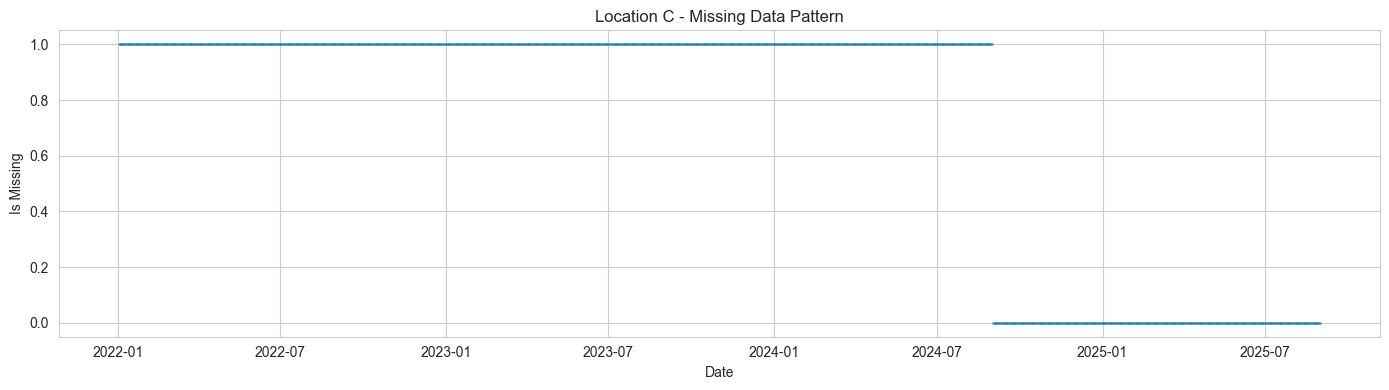

Location C first valid date: 2024-09-01 00:00:00


In [4]:
# Visualize missing data pattern for Location C
fig, ax = plt.subplots(figsize=(14, 4))
missing_c = df['location_C'].isnull()
ax.scatter(df['date'], missing_c, alpha=0.5, s=1)
ax.set_xlabel('Date')
ax.set_ylabel('Is Missing')
ax.set_title('Location C - Missing Data Pattern')
plt.tight_layout()
plt.show()

# Find when Location C data starts
first_valid_c = df[df['location_C'].notna()]['date'].min()
print(f"Location C first valid date: {first_valid_c}")

## 3. Time Series Visualization

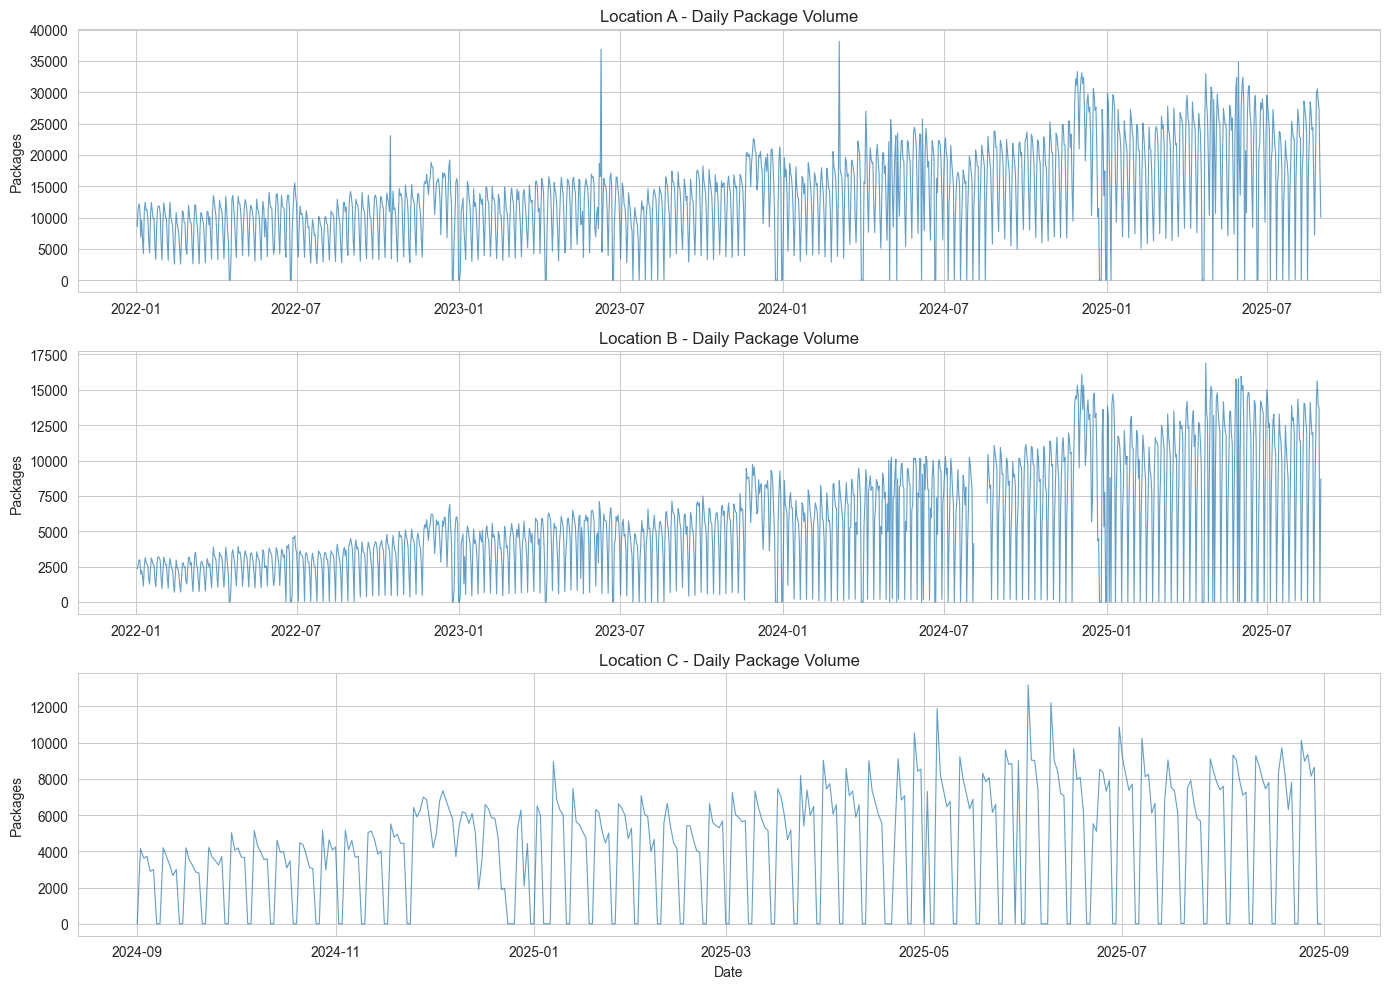

In [5]:
# Plot all three locations
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

locations = ['A', 'B', 'C']
for i, loc in enumerate(locations):
    col = f'location_{loc}'
    axes[i].plot(df['date'], df[col], alpha=0.7, linewidth=0.8)
    axes[i].set_title(f'Location {loc} - Daily Package Volume')
    axes[i].set_ylabel('Packages')
    if i == 2:
        axes[i].set_xlabel('Date')

plt.tight_layout()
plt.show()

## 4. Statistical Summary

In [6]:
# Summary statistics
summary = df[['location_A', 'location_B', 'location_C']].describe()
print("Summary statistics:")
print(summary)

Summary statistics:
         location_A    location_B    location_C
count   1338.000000   1324.000000    365.000000
mean   13763.831839   5610.080060   4401.304110
std     7206.151542   3896.544518   3269.466977
min        0.000000      0.000000      0.000000
25%     9124.750000   2889.250000      3.000000
50%    13126.000000   5037.500000   5026.000000
75%    18110.250000   8197.000000   6873.000000
max    38136.000000  16882.000000  13180.000000


## 5. Seasonality Check (Weekly Pattern)

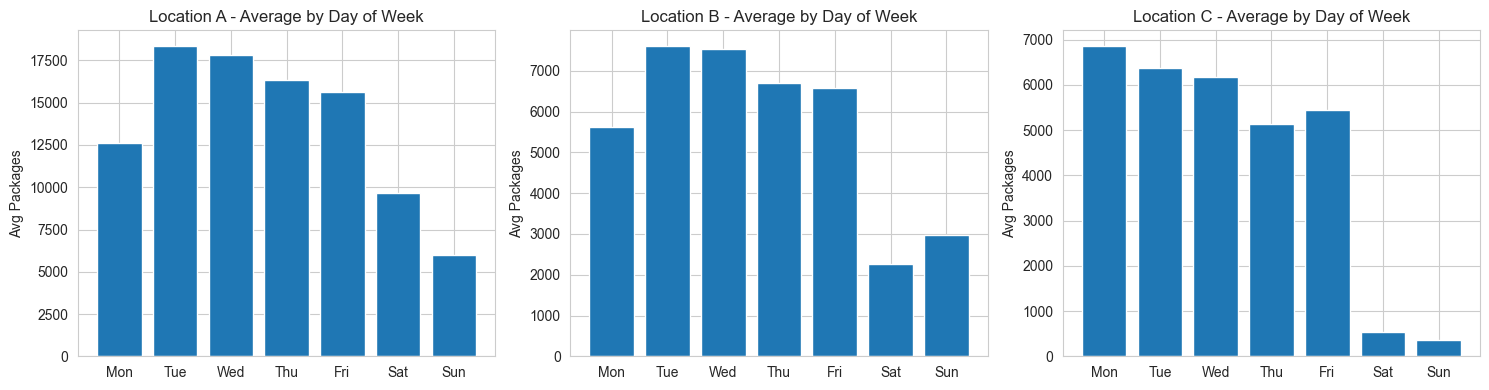

In [7]:
# Add day of week
df['day_of_week'] = df['date'].dt.day_name()
df['weekday'] = df['date'].dt.weekday

# Average by day of week for Location A
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, loc in enumerate(['A', 'B', 'C']):
    col = f'location_{loc}'
    # Filter out nulls for Location C
    temp_df = df[df[col].notna()].copy()
    weekly = temp_df.groupby('day_of_week')[col].mean().reindex(day_order)
    
    axes[i].bar(range(7), weekly.values)
    axes[i].set_xticks(range(7))
    axes[i].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    axes[i].set_title(f'Location {loc} - Average by Day of Week')
    axes[i].set_ylabel('Avg Packages')

plt.tight_layout()
plt.show()

## 6. Recent Trend (Last 90 Days)

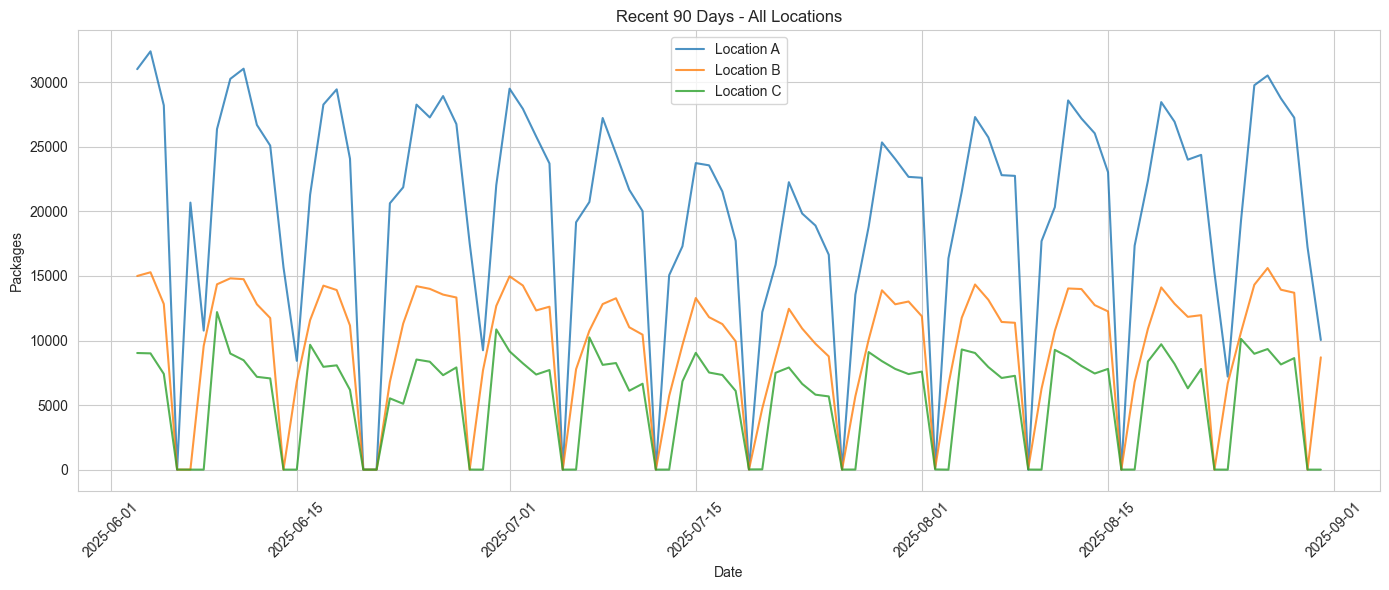

In [8]:
# Plot recent 90 days
recent_df = df.tail(90)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(recent_df['date'], recent_df['location_A'], label='Location A', alpha=0.8)
ax.plot(recent_df['date'], recent_df['location_B'], label='Location B', alpha=0.8)
ax.plot(recent_df['date'], recent_df['location_C'], label='Location C', alpha=0.8)
ax.legend()
ax.set_xlabel('Date')
ax.set_ylabel('Packages')
ax.set_title('Recent 90 Days - All Locations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Findings

1. **Location C Cold Start**: Location C only has data starting from around September 2024, while A and B have data from January 2022.

2. **Weekly Seasonality**: All locations show clear weekly patterns (lower volumes on weekends).

3. **Volume Differences**: Locations have different scales - this justifies separate models.

4. **Data Quality**: A and B have complete data; C requires special handling for its shorter history.